<a href="https://colab.research.google.com/github/jayasuneja/FWE458_Spring25/blob/main/Homework7_Suneja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 7

## Problem 1: Logistic Regression with ROC Analysis (4 pts)

Dataset: Iris Dataset (Binary Classification: Setosa vs. Non-Setosa)

Info on Iris Dataset:
* Contains measurements for 150 iris flowers
* 50 samples from each of the three species: Iris setosa, Iris versicolor, and Iris virginica
* Separating the setosa from the other two species is easy intro for machine learning because the setosa petal is usually less than 2 cm long and 0.6 cm wide; the other two species have much larger and longer petals
* Simple approach: if the petal length is less than 2cm -- it's setosa, otherwise, it's non-setosa

Task: Perform logistic regression classification with the following analysis:

Confusion Matrix:
 [[30  0]
 [ 0 15]]


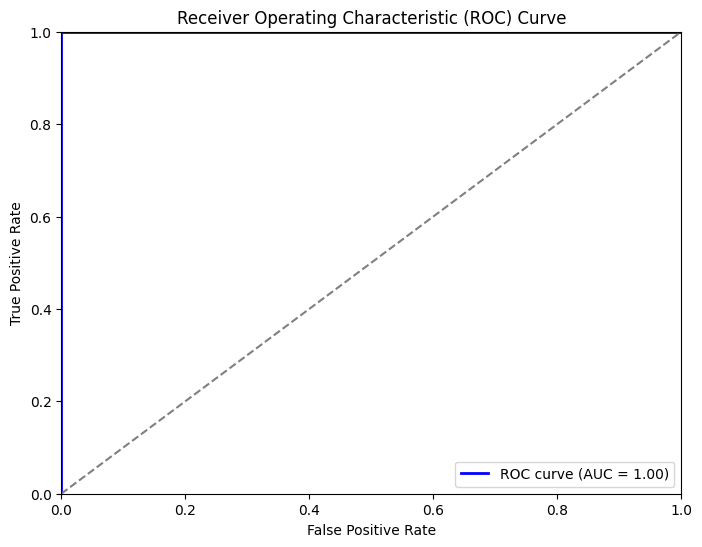

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-score: 1.00


In [1]:
# Load necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix

# Load the Iris dataset
X, y = datasets.load_iris(return_X_y=True)

# Convert to a binary classification problem (Setosa vs. Non-Setosa)
y = (y == 0).astype(int)  # Setosa = 1, Non-Setosa = 0

# Select only two features (optional, but helps visualization)
X = X[:, [2, 3]]  # Using only Petal Length and Petal Width

# Split dataset into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y, shuffle=True
)

# Train Logistic Regression model (no need for multi_class='ovr' in binary classification)
logreg = LogisticRegression(solver='liblinear')  # Solver suited for small datasets
logreg.fit(X_train, y_train)

# Predict class labels and probabilities
y_pred = logreg.predict(X_test)  # Predicted labels
y_prob = logreg.predict_proba(X_test)[:, 1]  # Probabilities for ROC curve

# Compute Confusion Matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cnf_matrix)

# Compute ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal reference line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Finding the accuracy, precision, recall, and F1 score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix
)

# Compute Classification Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")



My analysis of the iris dataset seems to conclude that it correctly classifies all positive and negative cases. This is a surprising result, and this could mean that the difference between the setosa and non-setosa species is so great that it is 'easy' for the model to pick up on and characterize with new data.

(If I did this wrong and the ROC curve should not be perfect, please let me know! I have limited knowledge on iris species)

## Problem 2: SVM with Kernel Selection (6 pts)

Dataset: Wine Dataset (Multiclass classification)



In [ ]:
# Load necessary libraries
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the Wine dataset
wine = datasets.load_wine()
X = wine.data  # Features
y = wine.target  # Target labels (Multiclass classification)

# Split dataset into 75% training and 25% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y, shuffle=True
)

# Define different kernels
kernels = ['linear', 'rbf', 'poly']

# Dictionary to store results
results = []

# Train and evaluate models for each kernel
for kernel in kernels:

    # Train SVM model
    svm_model = SVC(kernel=kernel, random_state=42)
    svm_model.fit(X_train, y_train)

    # Make predictions
    y_pred = svm_model.predict(X_test)

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store results
    results.append([kernel, accuracy, precision, recall, f1])

# Convert results into a DataFrame for better visualization
df_results = pd.DataFrame(results, columns=['Kernel', 'Accuracy', 'Precision', 'Recall', 'F1-score'])

# Convert results into a DataFrame for better visualization
df_results = pd.DataFrame(results, columns=['Kernel', 'Accuracy', 'Precision', 'Recall', 'F1-score'])

# Print results in a simple format
print("\nSVM Performance Comparison:")
print(df_results.to_string(index=False))


SVM Performance Comparison:
Kernel  Accuracy  Precision   Recall  F1-score
linear  0.955556   0.960000 0.955556  0.954705
   rbf  0.711111   0.670498 0.711111  0.651462
  poly  0.711111   0.832258 0.711111  0.644427


The performance comparison of the different SVM kernels in the Wine dataset reveals that the linear kernel performs the best compared to RBF and Polynomial kernels. The linear kernel accuracy out performs the other two by over 20%, which makes it a strong choice for discerning the wine. It is interesting that the RBF and polynomial kernels have the exact same accuracy and recall of 0.711 or 71.1%, but this is no match for the linear kernel's peformance regardless. This suggests that this dataset's feature space can be efficiently separated using a linear boundary instead of a more complex method of transformation. The linear kernel also has the highest F1-score, which measures the balance of precision and recall. This means that the linear kernel has a strong ability to predict performance while reducing the number of false positives and false negatives.